# Abercrombie Trademark Classification: TypeSafe vs. Claude Fable

This notebook classifies trademark descriptions from the LegalBench Abercrombie test set into one of five categories — generic, descriptive, suggestive, arbitrary, fanciful — using two different models: TypeSafe and Claude Fable. It compares their accuracy and speed.

In [1]:
import json
import os
import time

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from huggingface_hub import hf_hub_download
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from tqdm.auto import tqdm

load_dotenv()

True

## Configuration

Model names, dataset sample size, and other settings you might want to change live here.

In [2]:
# Abercrombie spectrum, from least to most distinctive
ABERCROMBIE_LABELS = ["generic", "descriptive", "suggestive", "arbitrary", "fanciful"]

LABEL_CRITERIA = {
    "generic": "The term is the common name for the product itself and cannot function as a trademark.",
    "descriptive": "The term directly describes a quality, feature, or characteristic of the product.",
    "suggestive": "The term hints at a quality of the product but requires imagination to make the connection.",
    "arbitrary": "The term is a common word used in a way that has nothing to do with its ordinary meaning applied to the product.",
    "fanciful": "The term is an invented word with no dictionary meaning, created specifically as a trademark.",
}

TYPESAFE_MODEL = None  # None uses the account's default model; see client.models.list() for the available options
FABLE_MODEL = "claude-fable-5"
FABLE_EFFORT = "low"  # "low" | "medium" | "high" | "xhigh" | "max" — raise this if accuracy matters more than speed
HAIKU_MODEL = "claude-haiku-4-5"  # older/smaller model; no effort setting, included as a speed/cost baseline

SAMPLE_SIZE = None  # set to an int to try a subset instead of the full 95 rows

## Load the dataset

Download the Abercrombie test set from the LegalBench dataset on Hugging Face and load it into a table. Each row has a trademark description and its correct label.

In [3]:
dataset_path = hf_hub_download(
    repo_id="nguha/legalbench",
    repo_type="dataset",
    filename="data/abercrombie/test.tsv",
    token=os.environ.get("HF_TOKEN"),
)

df = pd.read_csv(dataset_path, sep="\t").rename(columns={"answer": "true_label"})
if SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=0).reset_index(drop=True)

print(f"{len(df)} rows")
display(df["true_label"].value_counts().reindex(ABERCROMBIE_LABELS))
df.head()

95 rows


true_label
generic        19
descriptive    19
suggestive     19
arbitrary      19
fanciful       19
Name: count, dtype: int64

,index,true_label,text
0,0,generic,The mark “Salt” for packages of sodium chloride.
1,1,generic,"The mark ""Aspirin"" for inflammation medicine."
2,2,generic,"The mark ""Telephone"" for a portable device you..."
3,3,generic,"The mark ""Food"" for a restaurant."
4,4,generic,"The mark ""Kerosene"" for packages of flammable ..."


## TypeSafe classifier

Ask TypeSafe to pick one of the five labels for a given trademark description, and record how long the call took.

In [4]:
from typesafe_sdk import Choice, TypeSafeClient

typesafe_client = TypeSafeClient(api_key=os.environ["TYPESAFE_API_KEY"], model=TYPESAFE_MODEL)


def classify_with_typesafe(text: str) -> dict:
    start = time.perf_counter()
    result = typesafe_client.system_one(
        state=text,
        questions={
            "category": Choice(
                instructions="Classify this trademark description on the Abercrombie spectrum of trademark distinctiveness.",
                criteria=LABEL_CRITERIA,
            )
        },
    )
    latency = time.perf_counter() - start
    answer = result.answers["category"]
    return {"prediction": answer.choice, "confidence": answer.confidence, "latency": latency}

## Claude classifiers

Ask Claude Fable and Claude Haiku 4.5 the same question, using one shared Anthropic client. Both responses are constrained to a JSON object with one of the five labels, so they can't return anything else. Haiku 4.5 doesn't support the `effort` setting Fable uses, so its call leaves that out.

In [5]:
import anthropic

anthropic_client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

CLASSIFIER_SYSTEM_PROMPT = (
    "You are a trademark law expert. Classify the given trademark description on the "
    "Abercrombie spectrum of distinctiveness: generic, descriptive, suggestive, arbitrary, or fanciful."
)

CLASSIFIER_RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        "label": {"type": "string", "enum": ABERCROMBIE_LABELS},
        "confidence": {"type": "number", "description": "Confidence in the label, from 0 to 1."},
    },
    "required": ["label", "confidence"],
    "additionalProperties": False,
}


def classify_with_fable(text: str) -> dict:
    start = time.perf_counter()
    response = anthropic_client.beta.messages.create(
        model=FABLE_MODEL,
        max_tokens=512,
        system=CLASSIFIER_SYSTEM_PROMPT,
        messages=[{"role": "user", "content": text}],
        output_config={
            "format": {"type": "json_schema", "schema": CLASSIFIER_RESPONSE_SCHEMA},
            "effort": FABLE_EFFORT,
        },
        betas=["server-side-fallback-2026-07-01"],
        fallbacks="default",
    )
    latency = time.perf_counter() - start

    if response.stop_reason == "refusal":
        return {"prediction": None, "confidence": None, "latency": latency}

    text_block = next(block.text for block in response.content if block.type == "text")
    data = json.loads(text_block)
    return {"prediction": data["label"], "confidence": data["confidence"], "latency": latency}

In [6]:
def classify_with_haiku(text: str) -> dict:
    start = time.perf_counter()
    response = anthropic_client.messages.create(
        model=HAIKU_MODEL,
        max_tokens=512,
        system=CLASSIFIER_SYSTEM_PROMPT,
        messages=[{"role": "user", "content": text}],
        output_config={"format": {"type": "json_schema", "schema": CLASSIFIER_RESPONSE_SCHEMA}},
    )
    latency = time.perf_counter() - start

    if response.stop_reason == "refusal":
        return {"prediction": None, "confidence": None, "latency": latency}

    text_block = next(block.text for block in response.content if block.type == "text")
    data = json.loads(text_block)
    return {"prediction": data["label"], "confidence": data["confidence"], "latency": latency}

## Run both models over the dataset

For each row, get a prediction from each model and record the label, confidence, and time taken.

In [7]:
typesafe_results = [classify_with_typesafe(t) for t in tqdm(df["text"], desc="TypeSafe")]
fable_results = [classify_with_fable(t) for t in tqdm(df["text"], desc="Claude Fable")]
haiku_results = [classify_with_haiku(t) for t in tqdm(df["text"], desc="Claude Haiku 4.5")]

results = df.copy()
results["typesafe_pred"] = [r["prediction"] for r in typesafe_results]
results["typesafe_confidence"] = [r["confidence"] for r in typesafe_results]
results["typesafe_latency"] = [r["latency"] for r in typesafe_results]
results["fable_pred"] = [r["prediction"] for r in fable_results]
results["fable_confidence"] = [r["confidence"] for r in fable_results]
results["fable_latency"] = [r["latency"] for r in fable_results]
results["haiku_pred"] = [r["prediction"] for r in haiku_results]
results["haiku_confidence"] = [r["confidence"] for r in haiku_results]
results["haiku_latency"] = [r["latency"] for r in haiku_results]

results.head()

TypeSafe:   0%|          | 0/95 [00:00<?, ?it/s]

Claude Fable:   0%|          | 0/95 [00:00<?, ?it/s]

Claude Haiku 4.5:   0%|          | 0/95 [00:00<?, ?it/s]

,index,true_label,text,typesafe_pred,typesafe_confidence,typesafe_latency,fable_pred,fable_confidence,fable_latency,haiku_pred,haiku_confidence,haiku_latency
0,0,generic,The mark “Salt” for packages of sodium chloride.,generic,0.99,0.444621,generic,0.99,2.996014,generic,0.95,1.147527
1,1,generic,"The mark ""Aspirin"" for inflammation medicine.",generic,0.58,0.182048,generic,0.95,2.900081,generic,0.95,1.125174
2,2,generic,"The mark ""Telephone"" for a portable device you...",generic,0.93,0.196352,generic,0.97,2.974714,generic,0.99,0.606611
3,3,generic,"The mark ""Food"" for a restaurant.",generic,0.66,0.250172,generic,0.95,2.959897,generic,0.98,0.596066
4,4,generic,"The mark ""Kerosene"" for packages of flammable ...",generic,0.90,0.190593,generic,0.85,3.131137,generic,0.95,0.673192


## Accuracy

Compare each model's predictions to the correct labels.

In [8]:
typesafe_accuracy = accuracy_score(results["true_label"], results["typesafe_pred"])
fable_accuracy = accuracy_score(results["true_label"], results["fable_pred"])
haiku_accuracy = accuracy_score(results["true_label"], results["haiku_pred"])

print(f"TypeSafe accuracy: {typesafe_accuracy:.1%}\n")
print(classification_report(results["true_label"], results["typesafe_pred"], labels=ABERCROMBIE_LABELS))

print(f"\nClaude Fable accuracy: {fable_accuracy:.1%}\n")
print(classification_report(results["true_label"], results["fable_pred"], labels=ABERCROMBIE_LABELS))

print(f"\nClaude Haiku 4.5 accuracy: {haiku_accuracy:.1%}\n")
print(classification_report(results["true_label"], results["haiku_pred"], labels=ABERCROMBIE_LABELS))

TypeSafe accuracy: 76.8%

              precision    recall  f1-score   support

     generic       1.00      0.95      0.97        19
 descriptive       0.73      1.00      0.84        19
  suggestive       0.50      0.47      0.49        19
   arbitrary       0.80      0.63      0.71        19
    fanciful       0.83      0.79      0.81        19

    accuracy                           0.77        95
   macro avg       0.77      0.77      0.76        95
weighted avg       0.77      0.77      0.76        95


Claude Fable accuracy: 87.4%

              precision    recall  f1-score   support

     generic       1.00      1.00      1.00        19
 descriptive       0.79      0.79      0.79        19
  suggestive       0.70      0.74      0.72        19
   arbitrary       0.90      0.95      0.92        19
    fanciful       1.00      0.89      0.94        19

    accuracy                           0.87        95
   macro avg       0.88      0.87      0.87        95
weighted avg       0

## Confusion matrices

Each matrix shows how often a model predicted each label for rows with a given true label. The diagonal is correct predictions; everything off the diagonal is a mistake. Labels are ordered along the actual Abercrombie spectrum, so a mistake between neighboring categories (like suggestive vs. descriptive) is easy to tell apart from a bigger miss (like generic vs. fanciful). Both matrices share the same color scale, so darkness can be compared directly between them.

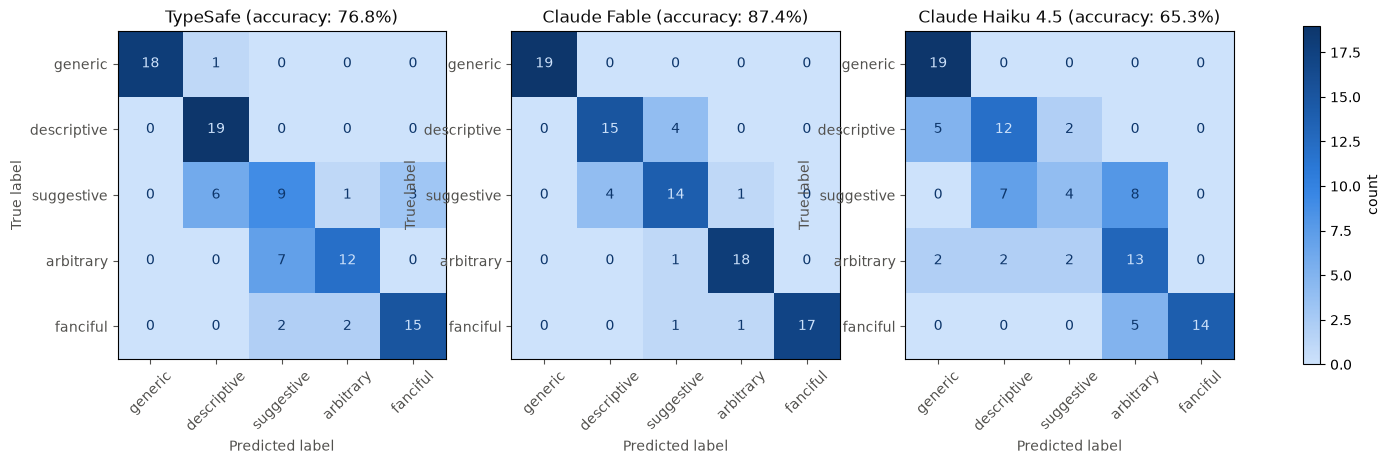

In [9]:
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue",
    ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
     "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"],
)

cm_typesafe = confusion_matrix(results["true_label"], results["typesafe_pred"], labels=ABERCROMBIE_LABELS)
cm_fable = confusion_matrix(results["true_label"], results["fable_pred"], labels=ABERCROMBIE_LABELS)
cm_haiku = confusion_matrix(results["true_label"], results["haiku_pred"], labels=ABERCROMBIE_LABELS)
shared_vmax = max(cm_typesafe.max(), cm_fable.max(), cm_haiku.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, cm, title, acc in [
    (axes[0], cm_typesafe, "TypeSafe", typesafe_accuracy),
    (axes[1], cm_fable, "Claude Fable", fable_accuracy),
    (axes[2], cm_haiku, "Claude Haiku 4.5", haiku_accuracy),
]:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ABERCROMBIE_LABELS)
    disp.plot(ax=ax, cmap=SEQ_BLUE, colorbar=False, im_kw={"vmin": 0, "vmax": shared_vmax})
    ax.set_title(f"{title} (accuracy: {acc:.1%})", color="#0b0b0b")
    ax.tick_params(axis="x", labelrotation=45, colors="#52514e")
    ax.tick_params(axis="y", colors="#52514e")
    ax.set_xlabel(ax.get_xlabel(), color="#52514e")
    ax.set_ylabel(ax.get_ylabel(), color="#52514e")

fig.colorbar(axes[0].images[0], ax=axes, shrink=0.8, label="count")
plt.show()

## Accuracy and speed, side by side

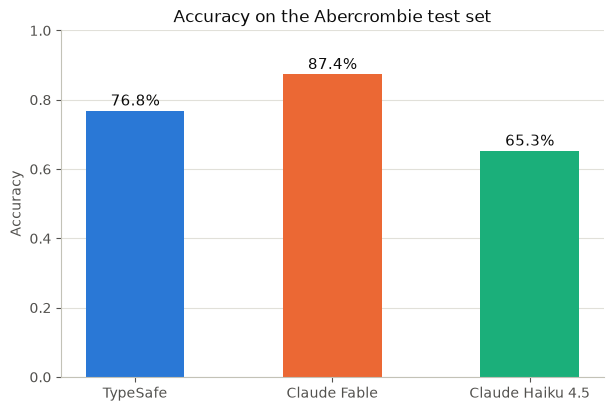

In [10]:
MODEL_NAMES = ["TypeSafe", "Claude Fable", "Claude Haiku 4.5"]
MODEL_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]

fig, ax = plt.subplots(figsize=(7, 4.5))
accuracies = [typesafe_accuracy, fable_accuracy, haiku_accuracy]
bars = ax.bar(MODEL_NAMES, accuracies, color=MODEL_COLORS, width=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015, f"{acc:.1%}",
            ha="center", color="#0b0b0b", fontsize=11)

ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy", color="#52514e")
ax.set_title("Accuracy on the Abercrombie test set", color="#0b0b0b")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

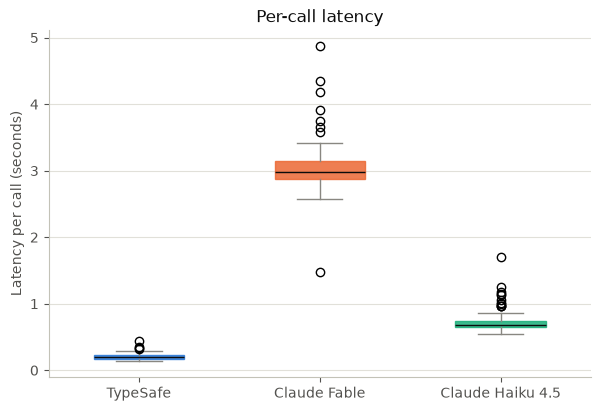

,typesafe_latency,fable_latency,haiku_latency
mean,0.202982,3.050116,0.731484
median,0.194739,2.980368,0.684461
<lambda>,0.281406,3.682079,1.071917


In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bp = ax.boxplot(
    [results["typesafe_latency"], results["fable_latency"], results["haiku_latency"]],
    patch_artist=True,
    widths=0.5,
)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(MODEL_NAMES)

for patch, color in zip(bp["boxes"], MODEL_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor(color)
for element in ("whiskers", "caps"):
    for line in bp[element]:
        line.set_color("#898781")
for median in bp["medians"]:
    median.set_color("#0b0b0b")

ax.set_ylabel("Latency per call (seconds)", color="#52514e")
ax.set_title("Per-call latency", color="#0b0b0b")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

results[["typesafe_latency", "fable_latency", "haiku_latency"]].agg(["mean", "median", lambda s: s.quantile(0.95)])

## Where the models disagreed

Rows where TypeSafe, Claude Fable, and Claude Haiku 4.5 didn't all pick the same label, for a closer look.

In [12]:
disagreements = results[
    (results["typesafe_pred"] != results["fable_pred"])
    | (results["typesafe_pred"] != results["haiku_pred"])
]
print(f"{len(disagreements)} of {len(results)} rows disagree")
disagreements[["text", "true_label", "typesafe_pred", "fable_pred", "haiku_pred"]]

36 of 95 rows disagree


,text,true_label,typesafe_pred,fable_pred,haiku_pred
16,"The mark ""Pictures"" for a photography service.",generic,descriptive,generic,generic
19,The mark “Sharp” for a television.,descriptive,descriptive,suggestive,descriptive
20,"The mark ""Trim"" for nail clippers.",descriptive,descriptive,suggestive,generic
24,"The mark ""Sharp"" for televisions.",descriptive,descriptive,suggestive,descriptive
26,"The mark ""Soft"" for pillows.",descriptive,descriptive,descriptive,generic
29,"The mark ""Compact"" for wallets.",descriptive,descriptive,descriptive,generic
30,"The mark ""Speedy"" for a bus service.",descriptive,descriptive,descriptive,suggestive
31,"The mark ""Best Washing"" for a laundromat.",descriptive,descriptive,descriptive,generic
34,"The mark ""QuickClean"" for towels.",descriptive,descriptive,suggestive,suggestive
36,"The mark ""Unique Haircuts"" for a hair salon.",descriptive,descriptive,descriptive,generic


## Summary

In [13]:
accuracies = {"TypeSafe": typesafe_accuracy, "Claude Fable": fable_accuracy, "Claude Haiku 4.5": haiku_accuracy}
mean_latencies = {
    "TypeSafe": results["typesafe_latency"].mean(),
    "Claude Fable": results["fable_latency"].mean(),
    "Claude Haiku 4.5": results["haiku_latency"].mean(),
}

most_accurate = max(accuracies, key=accuracies.get)
fastest = min(mean_latencies, key=mean_latencies.get)

for name in MODEL_NAMES:
    print(f"{name}: {accuracies[name]:.1%} accuracy, {mean_latencies[name]:.2f}s average latency")

print(f"\n{most_accurate} was the most accurate. {fastest} was the fastest.")

TypeSafe: 76.8% accuracy, 0.20s average latency
Claude Fable: 87.4% accuracy, 3.05s average latency
Claude Haiku 4.5: 65.3% accuracy, 0.73s average latency

Claude Fable was the most accurate. TypeSafe was the fastest.
